# Lecture 4 — Off-Policy Control with Linear Function Approximation

**Reinforcement Learning, 2025-26**

## Where we are

Lecture 3 introduced linear value function approximation and the simplest control algorithm built on top of it: semi-gradient Q-learning with two families of feature maps, tile coding and radial basis functions. On the continuous-state microbe with mild stochasticity, both feature kernels produced agents that learned reasonable policies; the learning curves converged, the value functions respected the structure of the dish, and the rollouts looked sensible.

We were also explicit, near the end of that lecture, that this comfortable picture rests on choices we did not justify. We dropped the second term of the gradient and called the result a *semi-gradient* update. We mentioned in passing that this update has no convergence guarantee in the off-policy case — and Q-learning, with its $\max_a$ in the bootstrap target, *is* off-policy. We even saw a small numerical hint of trouble in the form of RBF features that needed explicit normalisation to keep the weights from drifting. We deferred the proper discussion of why all this matters.

This lecture is that discussion. We will see, on a slightly modified version of the same environment, that the picture from Lecture 3 was less robust than it looked — and we will identify, name, and make precise the structural reason.

## What you will learn today

By the end of this lecture you will be able to:

1. Recognise the structural distinction between on-policy and off-policy methods in the function approximation setting, and the asymmetry of their convergence properties in the linear case.
2. Implement the on-policy counterpart of Lecture 3's Q-learning agent — `LinearSARSAAgent` — and read the behavioural differences between the two on a shared environment.
3. State precisely what the *deadly triad* is and why each of its three ingredients is necessary for divergence in the linear case.
4. Work through Baird's counterexample, the canonical demonstration that linear Q-learning can diverge on a perfectly innocuous-looking problem.
5. Describe the principal remedies — target networks, experience replay, gradient TD methods, on-policy alternatives — with enough understanding to motivate the architectural choices of deep Q-learning in Lecture 5.

## How we will get there

We open with a small change to Lecture 3's environment: **the microbe now lives in a fluid current** — a constant velocity field added to every step on top of the existing Gaussian noise. The reward function and the geometry of the dish are unchanged; only the dynamics differ. We retrain `LinearQLearningAgent` from Lecture 3 on this new environment, with reasonable hyperparameters, and we look at what it produced. The result motivates the rest of the lecture.

We then propose the on-policy counterpart — `LinearSARSAAgent` — and observe that it copes more gracefully under the same conditions. From this empirical asymmetry we extract the abstract lesson, the *deadly triad*: the combination of bootstrapping, off-policy learning, and function approximation, each pair of which is benign and the union of which is dangerous. We verify the lesson under controlled conditions on a constructed problem due to Baird, where the divergence is geometric and certified. We close with a brief tour of the standard remedies and a short bridge to Lecture 5, where these remedies move from the periphery of the algorithm to the centre of the architecture.

The new environment lives in `rlc/envs/windy_microbe.py`; the new agent in `rlc/agents/linear_sarsa.py`. Baird's MDP and the target-network variant are constructed inline in this notebook, in keeping with their role as one-shot demonstrations rather than reusable course tools.

## The problem: a microbe in moving water

In Lecture 3 we placed the microbe in a still Petri dish. Each step's displacement was the commanded direction plus a small isotropic Gaussian fluctuation; the fluid itself was inert, with no preferred direction. This was a useful idealisation, but it omits something any organism in any real fluid contends with: the fluid is rarely still. Currents, convection, and gradients of temperature or concentration all bias motion in directions the organism did not choose.

We model this in the simplest possible way: a constant velocity field $\mathbf{c} \in \mathbb{R}^2$ — a uniform drift, the same at every point of the dish — added to the displacement at every step. Before clipping to the dish boundary, the new transition rule is

$$s_{\mathrm{landing}} = s + \Delta \, \hat{\mathbf{a}} + \mathbf{c} + \boldsymbol{\eta}, \qquad \boldsymbol{\eta} \sim \mathcal{N}(0, \sigma^2 I),$$

with $\Delta$ the per-action displacement magnitude (1.0, as in Lecture 3), $\hat{\mathbf{a}}$ the unit vector of the commanded action, and $\boldsymbol{\eta}$ the same Gaussian fluctuation we already had. Reward, geometry, and termination are unchanged: the dish is still 12×6, the toxic rectangle still runs along the bottom edge, the goal disc is still in the bottom-right corner, and the toxic-teleport mechanism is still in place. We are perturbing the *dynamics* and nothing else.

The pedagogical point of this modification is not that it makes the problem dramatically harder in absolute terms. The optimal policy on the windy microbe is still a sequence of moves to the goal — possibly different from the still-dish policy near the toxic band, but qualitatively similar — and a competent algorithm should still be able to find it. The point is more delicate, and it concerns the *distribution of states the agent visits during training* relative to the distribution of states it would visit under the policy it is trying to learn.

Under the still dish, these two distributions, while not identical, were close: the ε-greedy behaviour wandered around a manifold not too far from the optimal trajectory. Under a wind, this stops being true. A microbe under uniformly random or ε-greedy exploration is dragged by the current — its visited states get biased in the direction of $\mathbf{c}$, regardless of which actions it commands. A microbe following the optimal policy fights or surfs the current depending on the alignment of $\mathbf{c}$ with its target direction. The two distributions can overlap less than they did in the still dish, and as we will see, it is exactly this kind of asymmetry that off-policy methods are sensitive to.

For now we leave this observation as a hint and act. We import `LinearQLearningAgent` from Lecture 3, instantiate it with the RBF features that worked there, train it on the windy environment with the same schedule, and look at what we get.

## Implementation: a windy microbe

We implement the new dynamics as a subclass of `ContinuousMicrobeEnv` rather than as a parameter on the existing class. The motivation is twofold. First, `ContinuousMicrobeEnv` is the environment of Lecture 3 and is referenced by other notebooks; modifying its constructor in a way that affects existing call sites would be poor hygiene. Second, the override needed is small and self-contained — only the `_intended_landing` method changes — and a subclass keeps the diff visible at a glance.

The override introduces a `current` attribute, a 2D vector $\mathbf{c}$ with default value zero, and adjusts the displacement computation by a single line: the drift is added to the per-action displacement before the noise term and before the clipping to the dish boundary. With `current=(0, 0)` the subclass is operationally identical to its parent. Everything else — the toxic teleport, the clipping to bounds, the reward function, the rendering — is inherited unchanged.

The module lives in `rlc/envs/windy_microbe.py`.

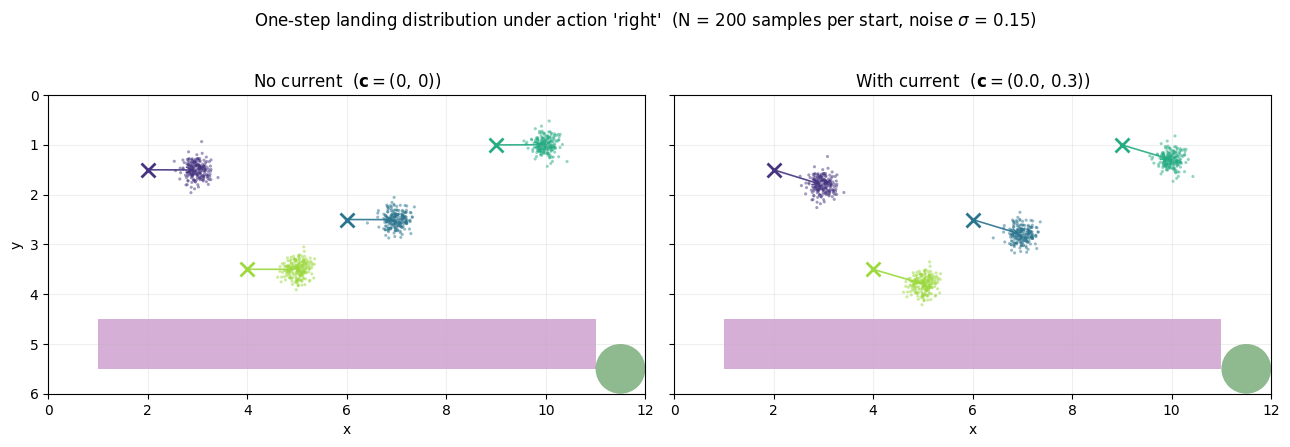

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from rlc.envs.windy_microbe import WindyMicrobeEnv


# Configuration: a single fixed action, matched noise across panels.
ACTION = 1  # "right"
ACTION_NAMES = {0: "up", 1: "right", 2: "down", 3: "left"}
N_SAMPLES = 200
NOISE = 0.15
CURRENT_DEMO = (0.0, 0.3)  # purely downward drift, for illustration only

# Start positions distributed across the dish, all comfortably outside the
# toxic band so the unclipped landing distribution is fully visible.
START_POSITIONS = [
    (2.0, 1.5),
    (6.0, 2.5),
    (9.0, 1.0),
    (4.0, 3.5),
]
COLORS = plt.cm.viridis(np.linspace(0.15, 0.85, len(START_POSITIONS)))


def sample_one_step_landings(env, start, action, n_samples):
    """Sample n_samples landing positions from `start` after `action`,
    using env._intended_landing directly. The method does not modify env
    state and is the cleanest way to expose the one-step transition
    distribution.
    """
    start = np.asarray(start, dtype=np.float64)
    return np.stack([
        env._intended_landing(start.copy(), action) for _ in range(n_samples)
    ])


# Two envs that differ only in the drift.
env_still = WindyMicrobeEnv(current=(0.0, 0.0), noise=NOISE)
env_windy = WindyMicrobeEnv(current=CURRENT_DEMO, noise=NOISE)
env_still.reset(seed=0)
env_windy.reset(seed=0)


def draw_dish_layout(ax, env):
    xmin, ymin, xmax, ymax = env.toxic_rect
    ax.add_patch(mpatches.Rectangle(
        (xmin, ymin), xmax - xmin, ymax - ymin,
        facecolor="#8c1a8c", alpha=0.35, edgecolor="none",
    ))
    ax.add_patch(mpatches.Circle(
        env.goal_center, env.goal_radius,
        facecolor="#338033", alpha=0.55, edgecolor="none",
    ))
    ax.set_xlim(0, env.width)
    ax.set_ylim(env.height, 0)  # y increases downward
    ax.set_aspect("equal")
    ax.grid(alpha=0.2)


def plot_landings(ax, env, title):
    draw_dish_layout(ax, env)
    for start, color in zip(START_POSITIONS, COLORS):
        landings = sample_one_step_landings(env, start, ACTION, N_SAMPLES)
        ax.scatter(landings[:, 0], landings[:, 1],
                   s=5, color=color, alpha=0.5, edgecolors="none")
        ax.plot(start[0], start[1], marker="x", color=color,
                markersize=10, markeredgewidth=2.0)
        ax.annotate(
            "", xy=landings.mean(axis=0), xytext=start,
            arrowprops=dict(arrowstyle="->", color=color, alpha=0.9, lw=1.2),
        )
    ax.set_xlabel("x")
    ax.set_title(title)


fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
plot_landings(axes[0], env_still, r"No current  ($\mathbf{c} = (0,\, 0)$)")
c = env_windy.current
plot_landings(
    axes[1], env_windy,
    rf"With current  ($\mathbf{{c}} = ({c[0]:.1f},\, {c[1]:.1f})$)",
)
axes[0].set_ylabel("y")
fig.suptitle(
    f"One-step landing distribution under action '{ACTION_NAMES[ACTION]}'  "
    f"(N = {N_SAMPLES} samples per start, noise $\\sigma$ = {NOISE})",
)
fig.tight_layout()
plt.show()

## Retraining Q-learning on the windy microbe

In [2]:
import numpy as np

from rlc.envs.windy_microbe import WindyMicrobeEnv
from rlc.agents.linear_q_learning import LinearQLearningAgent
from rlc.utils.features import RBFFeatures
from rlc.utils.training import train


# --- Configuration ---
N_EPISODES = 1000
EVAL_EVERY = 50
EVAL_EPISODES = 20
MAX_STEPS_PER_EPISODE = 500
EVAL_MAX_STEPS = 500
MASTER_SEED = 42

NOISE = 0.05
CURRENT = (0.4, 0.4)
NOMINAL_ALPHA = 0.25   # bumped from L3's 0.15

# RBF feature configuration, identical to Lecture 3.
RBF_N_CENTERS_X = 26
RBF_N_CENTERS_Y = 18
RBF_SIGMA = 2.0

COMMON_AGENT = dict(
    gamma=1.0,
    epsilon_start=1.0,
    epsilon_min=0.05,
    epsilon_decay=0.997,
)

LOW = np.array([0.0, 0.0])
HIGH = np.array([12.0, 6.0])


# --- Instrumented agent ---
# The standard agent does not expose ||W|| over training, so we add a thin
# subclass that records the Frobenius norm at the end of each episode.

class TrackedLinearQLearningAgent(LinearQLearningAgent):
    """Linear Q-learning agent that records ||W||_F after each episode
    and the state passed to every update, for post-hoc diagnostic use."""

    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.weight_norms = [float(np.linalg.norm(self.W))]
        self.training_states = []

    def update(self, state, action, reward, next_state, terminated, *,
               next_action=None):
        self.training_states.append(np.asarray(state, dtype=np.float64).copy())
        super().update(state, action, reward, next_state, terminated,
                       next_action=next_action)

    def end_episode(self):
        super().end_episode()
        self.weight_norms.append(float(np.linalg.norm(self.W)))

# --- Train ---
features = RBFFeatures(
    low=LOW, high=HIGH,
    n_centers_x=RBF_N_CENTERS_X, n_centers_y=RBF_N_CENTERS_Y,
    sigma=RBF_SIGMA,
    normalize=True,
)
train_env = WindyMicrobeEnv(current=CURRENT, noise=NOISE)
eval_env = WindyMicrobeEnv(current=CURRENT, noise=NOISE)
agent = TrackedLinearQLearningAgent(
    feature_extractor=features,
    n_actions=train_env.action_space.n,
    alpha=NOMINAL_ALPHA,
    seed=MASTER_SEED + 1,
    **COMMON_AGENT,
)
history = train(
    agent, train_env,
    n_episodes=N_EPISODES,
    max_steps_per_episode=MAX_STEPS_PER_EPISODE,
    eval_every=EVAL_EVERY,
    eval_episodes=EVAL_EPISODES,
    eval_env=eval_env,
    eval_max_steps=EVAL_MAX_STEPS,
    seed=MASTER_SEED,
    progress=True,
)

print(f"\nFinal ||W||_F:      {agent.weight_norms[-1]:.3f}  "
      f"(initial: {agent.weight_norms[0]:.3f})")
print(f"Final eval return: {history.eval_mean_returns[-1]:.1f}  "
      f"(std {history.eval_std_returns[-1]:.1f})")
print(f"Final epsilon:     {agent.epsilon:.3f}")

Training:   0%|          | 0/1000 [00:00<?, ?ep/s]


Final ||W||_F:      2070.644  (initial: 0.000)
Final eval return: -1148.5  (std 154.9)
Final epsilon:     0.050


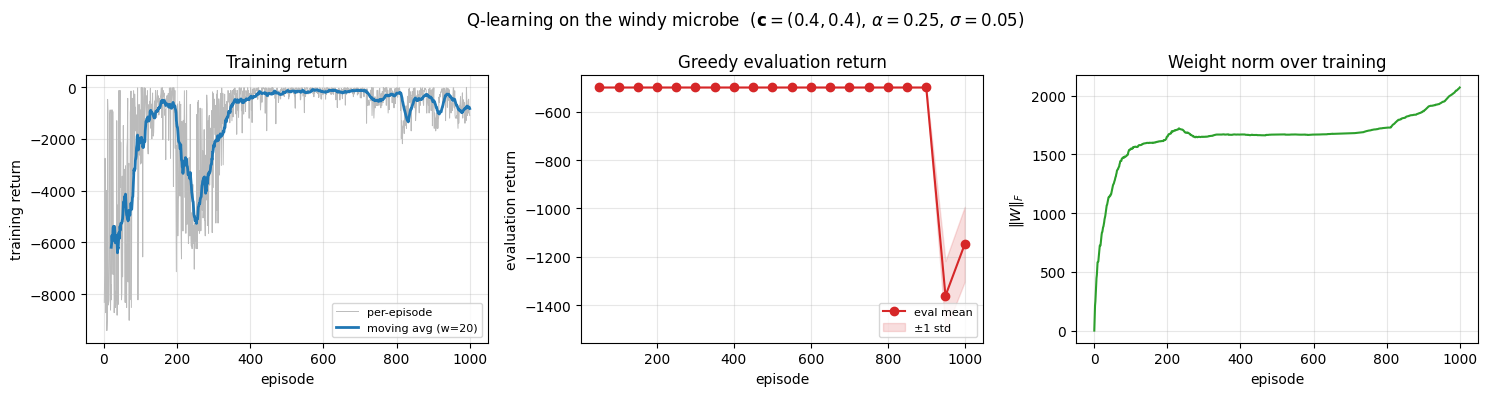

In [3]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# --- (1) Training return ---
ax = axes[0]
returns = np.asarray(history.episode_returns)
episodes = np.arange(1, len(returns) + 1)
ax.plot(episodes, returns, color="#bbbbbb", linewidth=0.7,
        label="per-episode")
window = 20
if len(returns) >= window:
    smoothed = np.convolve(returns, np.ones(window) / window, mode="valid")
    ax.plot(np.arange(window, len(returns) + 1), smoothed,
            color="#1f77b4", linewidth=2.0,
            label=f"moving avg (w={window})")
ax.set_xlabel("episode")
ax.set_ylabel("training return")
ax.set_title("Training return")
ax.legend(loc="lower right", fontsize=8)
ax.grid(alpha=0.3)

# --- (2) Evaluation return ---
ax = axes[1]
eval_eps = np.asarray(history.eval_episodes)
eval_means = np.asarray(history.eval_mean_returns)
eval_stds = np.asarray(history.eval_std_returns)
ax.plot(eval_eps, eval_means, marker="o", color="#d62728", linewidth=1.5,
        label="eval mean")
ax.fill_between(eval_eps, eval_means - eval_stds, eval_means + eval_stds,
                color="#d62728", alpha=0.15, label="±1 std")
ax.set_xlabel("episode")
ax.set_ylabel("evaluation return")
ax.set_title("Greedy evaluation return")
ax.legend(loc="lower right", fontsize=8)
ax.grid(alpha=0.3)

# --- (3) Weight norm ---
ax = axes[2]
norms = np.asarray(agent.weight_norms)
ax.plot(np.arange(len(norms)), norms, color="#2ca02c", linewidth=1.5)
ax.set_xlabel("episode")
ax.set_ylabel(r"$\|W\|_F$")
ax.set_title("Weight norm over training")
ax.grid(alpha=0.3)

fig.suptitle(
    rf"Q-learning on the windy microbe  "
    rf"($\mathbf{{c}} = {CURRENT}$, $\alpha = {NOMINAL_ALPHA}$, "
    rf"$\sigma = {NOISE}$)",
)
fig.tight_layout()
plt.show()

### A new diagnostic: the weight norm

In the tabular lectures we monitored the Q-table directly through value heatmaps and learning curves; table entries are individually meaningful, and the natural diagnostics are *spatial*. In the linear setting the parameters are no longer directly interpretable: $W$ is a matrix of feature weights, related to action-values only indirectly through $\hat{q}(s, a) = \mathbf{w}_a^\top \mathbf{x}(s)$. Two states with very different action-values can correspond to the same column of $W$ being touched, and the same value can be produced by very different $W$. To monitor *parameter health* rather than *value estimates* we therefore need a single scalar summary of the matrix, and the simplest such summary is the Frobenius norm $\|W\|_F = \sqrt{\sum_{a, i} W_{a, i}^2}$.

In a stable regime $\|W\|_F$ converges to a finite value, reflecting the magnitude of the value function being represented: the weights settle into a configuration that approximates the value of the policy and stop changing in any systematic way. In an unstable regime $\|W\|_F$ drifts upward without bound — the parameters grow larger without thereby representing anything more accurate, because the algorithm has no fixed point to which they could be converging. We did not need this diagnostic in Lecture 3, where everything converged cleanly; if we had plotted it there we would have seen a well-behaved plateau and the lecture's story would have been unchanged. The standard `train` utility therefore does not track $\|W\|_F$, and we instrument the agent here with a minimal subclass that records it at the end of every episode. The question for today is what shape that record takes.

The three panels read as one story.

The training return (left) shows the agent's behaviour-policy performance: noisy throughout, with a moving average that improves only weakly compared to the smooth descent we saw in Lecture 3. The greedy evaluation return (centre) — the quantity that actually measures policy quality — is worse, sometimes substantially worse, than the training return, and oscillates rather than settling. In Lecture 3 the two converged together. Here they do not.

The third panel — the weight norm $\|W\|_F$ — explains the shape of the failure. In Lecture 3 the norm grew rapidly in the first hundred episodes and then plateaued at a finite, well-behaved value; here it does not plateau in the same way, drifting upward well beyond the magnitude that the value function structurally requires. The greedy policy is reading off a noisy, mis-scaled function approximator, and the evaluation return reflects that.

Nothing about this picture is conclusive on its own. The training noise could be artefact; the moving average could improve later; the weight norm could plateau eventually. But the *shape* is the shape one associates with a representation that has no fixed point in the off-policy case — the algorithm is chasing a target that moves with the parameters, and the parameters are drifting rather than converging. The next sections give us the conceptual tools to say this precisely. For now, the diagnosis is informal: something that worked in Lecture 3 does not work here, and the most diagnostic single signal is that $\|W\|_F$ refuses to settle.

## On-policy and off-policy methods, revisited

The natural place to begin diagnosing what we saw is the *kind* of update Q-learning performs. We met this distinction informally in Lecture 2, when we contrasted SARSA and Q-learning side-by-side on the slippery microbe. There the difference manifested as a behavioural asymmetry: SARSA learned the cautious, cliff-distant policy; Q-learning learned the aggressive, cliff-edge one. The terminology we used was *on-policy* and *off-policy*, and for the tabular setting that was the end of the story — both algorithms converged, only the asymptotic policies differed. We are going to see in this lecture that the same distinction has structural consequences in the function approximation setting that go far beyond a difference in cliff-distance.

### Two distributions are always at play

A reinforcement learning algorithm acts on data sampled from one distribution to produce estimates that should be accurate under (possibly) another. The first is the **behaviour distribution** $\mu_b$: the law of $(s, a)$ pairs the agent actually experiences while learning, induced by the **behaviour policy** $\pi_b$ used for action selection. The second is the **target distribution** $\mu_\pi$: the law of $(s, a)$ pairs the algorithm's estimates are *intended* to evaluate, induced by the **target policy** $\pi$ whose value function $q_\pi$ the algorithm is trying to estimate. When the two distributions coincide we call the algorithm **on-policy**; when they differ we call it **off-policy**.

The distinction is invisible in *prediction* problems where the agent explicitly follows the policy whose value it is evaluating. It becomes structural in *control* problems, where the target policy is typically the *greedy* policy $\pi^*(s) = \arg\max_a \hat{q}(s, a; \mathbf{w})$ — defined implicitly as the best response to the current value estimate — while the behaviour policy must be exploratory in order for learning to be possible at all. Whether $\pi_b$ tracks $\pi^*$ or wanders away from it determines whether the algorithm is on- or off-policy.

### Q-learning is off-policy by construction

Consider Q-learning's update:

$$\mathbf{w}_a \leftarrow \mathbf{w}_a + \alpha \big[ R_{t+1} + \gamma \max_{a'} \hat{q}(S_{t+1}, a'; \mathbf{w}) - \hat{q}(S_t, A_t; \mathbf{w}) \big] \, \mathbf{x}(S_t).$$

The bootstrap term $\max_{a'} \hat{q}(S_{t+1}, a'; \mathbf{w})$ is the value of the *greedy* action at $S_{t+1}$, regardless of which action the behaviour policy will actually take. The target the algorithm is fitting is therefore $q_{\pi^*}$, the action-value function of the greedy policy. The data, however, is generated by $\pi_b$, the ε-greedy policy, which takes the greedy action only with probability $1 - \varepsilon + \varepsilon/|\mathcal{A}|$ at each step. The two policies coincide only in the limit $\varepsilon \to 0$, which we never run.

This is the structural sense in which Q-learning is off-policy: the $(s, a)$ pairs the algorithm sees come from a distribution different from the one its target evaluates. Contrast SARSA, whose update replaces $\max_{a'} \hat{q}(S_{t+1}, a'; \mathbf{w})$ with $\hat{q}(S_{t+1}, A_{t+1}; \mathbf{w})$, where $A_{t+1}$ is the action *actually* sampled from the behaviour policy. SARSA's target uses the same policy that generates its data: on-policy by construction.

### Why this was harmless in the tabular case

In the tabular setting, the off-policy nature of the algorithm is structurally there but does not interfere with convergence — because in the tabular setting each Q-table entry is updated independently of the others, the distribution of visited states only affects the *speed* of convergence, not the *existence* of the fixed point.

This independence is the structural protection that tabular representation buys: every state-action pair is its own parameter, and updating one cannot break another. The protection vanishes in the function approximation case, where every parameter affects the values at many states simultaneously.

### Why this matters in the linear case

For *prediction* — evaluating a fixed policy with TD(0) — there is a clean asymmetry between on- and off-policy with linear features.

In the on-policy case, linear semi-gradient TD converges, under mild conditions (linearly independent features, an ergodic Markov chain induced by the policy, a decreasing step size), to the unique fixed point of a contraction in a particular weighted norm. The fixed point is not the true value function in general (linear features cannot represent it exactly) but it is uniquely defined and the algorithm reaches it. A converged policy and a converged value estimate exist.

In the off-policy case, the same algorithm has no analogous guarantee. The composition of the Bellman operator with projection onto the linear subspace, taken in the off-policy weighted norm, is in general *no longer a contraction*; the iteration can fail to converge, and in some cases the parameters diverge geometrically. This is a structural fact about the off-policy projected Bellman operator and not a numerical artefact: even with infinite data, infinite computation, and a perfectly chosen step-size schedule, the algorithm has no fixed point to converge to.

For *control*, where the target policy itself changes over time as the value estimate changes, the theory is more delicate and the guarantees are weaker on both sides. But the broad pattern survives: on-policy linear methods are typically well-behaved, off-policy linear methods are not. Linear *Q-learning* — the algorithm we used in Lecture 3 and in the windy-microbe experiment — falls in the off-policy camp, and therefore in the camp without a convergence guarantee. The drifting weight norm we just observed is consistent with this absence: the parameters move because the algorithm is chasing a target that itself moves with the parameters, and there is no contraction available to damp the dynamic.

### Where the protection breaks

When parameters are shared across states, every TD update is no longer a local correction to a single Q-value but a global nudge to a function. Each transition $(s, a, r, s')$ applies a small force on $\mathbf{w}_a$ proportional to the TD error at $(s, a)$ and pointing along the feature vector $\mathbf{x}(s)$; two transitions at states with overlapping features pull on overlapping components of $\mathbf{w}_a$, with forces that may agree, disagree, or cancel. Whether the parameters settle depends on whether these forces, integrated over the data distribution, balance into a state of equilibrium.

On-policy data balances naturally. The data distribution matches the policy whose value is being learned, and the pulls — weighted by the visit frequencies of that policy — aggregate consistently with the structure of the bootstrap target. There is an equilibrium point, and the algorithm finds it. Off-policy data does not balance in the same way: the pulls are weighted by visits of the behaviour policy, while the bootstrap target's structure comes from a *different* policy. The forces can fail to cancel at any single point; in the worst case they amplify each other, and the parameters drift indefinitely — exactly the picture we saw on the windy microbe. In the tabular case parameters were independent and the data distribution affected only the *speed* of learning; in the function approximation case parameters are coupled, and the data distribution affects whether the algorithm has a fixed point at all.

### The natural question

If off-policy is at least *part* of the trouble, the obvious thing to try is on-policy. The natural on-policy counterpart of Q-learning is SARSA, which we know in its tabular form and which extends to linear function approximation by exactly the substitution that distinguishes the two algorithms in the first place: replace the $\max$ in the bootstrap by the value of the action actually sampled by the behaviour policy. The next section builds that algorithm.

## Linear SARSA: an on-policy counterpart

The substitution that turns Q-learning into SARSA is the smallest possible change to the update rule. Q-learning's bootstrap term used the value of the *greedy* action at the next state, $\max_{a'} \hat{q}(S_{t+1}, a'; \mathbf{w})$. SARSA replaces it with the value of the action *the behaviour policy actually sampled at the next state*, $\hat{q}(S_{t+1}, A_{t+1}; \mathbf{w})$:

$$\mathbf{w}_a \leftarrow \mathbf{w}_a + \alpha \big[ R_{t+1} + \gamma \, \hat{q}(S_{t+1}, A_{t+1}; \mathbf{w}) - \hat{q}(S_t, A_t; \mathbf{w}) \big] \, \mathbf{x}(S_t).$$

Everything else — the feature map, the parameter shape, the action selection, the overall agent contract — is unchanged. From the outside, the agent looks the same: it selects an action via ε-greedy on $\hat{q}$, it receives a transition, it applies a TD-style update. The only difference is which action's value it puts in the bootstrap.

### Why the substitution makes the algorithm on-policy

The change in the update is mechanical, but its consequence is structural. Recall from the previous section: an algorithm is on-policy when the data distribution it sees matches the distribution under which the bootstrap target is defined. SARSA's bootstrap is the value of the action $A_{t+1}$ sampled by the behaviour policy at $S_{t+1}$ — and that *same* action is what the agent will actually execute on the next step, generating the next data point. The data and the target are produced by the same policy, by construction. There is no mismatch between behaviour and target distributions, because there is no target policy distinct from the behaviour.

Concretely: if the behaviour policy is ε-greedy with the current $\varepsilon$, then SARSA learns the action-value function of *that ε-greedy policy* — not of the underlying greedy policy that Q-learning targets. As $\varepsilon$ decays toward a small floor, the policy SARSA evaluates approaches the greedy one, but is never exactly greedy unless $\varepsilon = 0$. This is a subtler convergence target than Q-learning's, but it is one for which the linear convergence theory of the previous section applies cleanly: the on-policy projected Bellman operator is a contraction in its weighted norm, and the algorithm has a fixed point.

### The expected behavioural consequences

In Lecture 2 we observed, on the slippery microbe, that tabular SARSA produced cautious policies that kept the agent away from the cliff edge, while Q-learning produced bold policies that hugged it. The same mechanism applies here, and for the same reason: SARSA factors the cost of *its own exploration* into the action-values, because exploration is part of the policy whose value it is computing. A state adjacent to the toxic band is dangerous under SARSA, because *with probability $\varepsilon$* the agent will randomly step into the band; under Q-learning the same state is fine, because the greedy policy never voluntarily enters the band, regardless of $\varepsilon$.

We expect to see the same asymmetry on the windy microbe — and to see, on top of it, the structural consequence that motivated this section: SARSA's $\|W\|_F$ should remain bounded under the same conditions in which Q-learning's drifted upwards. Whether this prediction holds is the empirical question of the next section.

### Implementing the linear SARSA agent

The implementation parallels `LinearQLearningAgent` exactly, with the differences confined to the body of `update`. Where Q-learning evaluates $\max_a \hat{q}(S_{t+1}, a; \mathbf{w})$ at the bootstrap step, SARSA looks up $\hat{q}(S_{t+1}, A_{t+1}; \mathbf{w})$ for the specific action `next_action` provided by the training loop. The training loop introduced in Lecture 1 already samples `next_action` before calling `update` and passes it as a keyword argument; we simply consume it here.

The same `Agent` protocol is satisfied — `select_action`, `update`, `end_episode` — and the same `feature_extractor` plug-in mechanism is supported. From the perspective of the training utilities and the diagnostic plots, the SARSA agent is interchangeable with the Q-learning one: anything that runs on `LinearQLearningAgent` runs on `LinearSARSAAgent`.

Two implementation details mirror those of the tabular SARSA agent of Lecture 2. First, the update raises an explicit `ValueError` if `next_action` is missing on a non-terminal transition: the SARSA contract requires that action, and silently falling back to a default would produce a subtly wrong algorithm. Second, on terminal transitions the bootstrap is zero by definition, and the update reduces to fitting the immediate reward — `next_action` is allowed to be `None` in this case.

The module lives in `rlc/agents/linear_sarsa.py`.

In [4]:
import numpy as np

from rlc.envs.windy_microbe import WindyMicrobeEnv
from rlc.agents.linear_sarsa import LinearSARSAAgent
from rlc.utils.features import RBFFeatures
from rlc.utils.training import train


# Reuse the trained Q-learning agent from the opening section under explicit names.
q_agent = agent
q_history = history


# Tracker for SARSA, mirroring the Q-learning one defined in the opening section.
class TrackedLinearSARSAAgent(LinearSARSAAgent):
    """Same as LinearSARSAAgent but records ||W||_F after each episode
    and the state passed to every update, mirroring the Q-learning tracker."""

    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.weight_norms = [float(np.linalg.norm(self.W))]
        self.training_states = []

    def update(self, state, action, reward, next_state, terminated, *,
               next_action=None):
        self.training_states.append(np.asarray(state, dtype=np.float64).copy())
        super().update(state, action, reward, next_state, terminated,
                       next_action=next_action)

    def end_episode(self):
        super().end_episode()
        self.weight_norms.append(float(np.linalg.norm(self.W)))

# Same env, same features, same schedule as the opening cell — we only train
# SARSA here, with a different seed offset for independent exploration.
s_features = RBFFeatures(
    low=LOW, high=HIGH,
    n_centers_x=RBF_N_CENTERS_X, n_centers_y=RBF_N_CENTERS_Y,
    sigma=RBF_SIGMA,
    normalize=True,
)
s_train_env = WindyMicrobeEnv(current=CURRENT, noise=NOISE)
s_eval_env = WindyMicrobeEnv(current=CURRENT, noise=NOISE)
s_agent = TrackedLinearSARSAAgent(
    feature_extractor=s_features,
    n_actions=s_train_env.action_space.n,
    alpha=NOMINAL_ALPHA,
    seed=MASTER_SEED + 2,
    **COMMON_AGENT,
)
s_history = train(
    s_agent, s_train_env,
    n_episodes=N_EPISODES,
    max_steps_per_episode=MAX_STEPS_PER_EPISODE,
    eval_every=EVAL_EVERY,
    eval_episodes=EVAL_EPISODES,
    eval_env=s_eval_env,
    eval_max_steps=EVAL_MAX_STEPS,
    seed=MASTER_SEED,
    progress=True,
)


print(f"\nQ-learning  | final ||W||_F: {q_agent.weight_norms[-1]:7.3f}  "
      f"final eval: {q_history.eval_mean_returns[-1]:7.1f}  "
      f"(std {q_history.eval_std_returns[-1]:.1f})")
print(f"SARSA       | final ||W||_F: {s_agent.weight_norms[-1]:7.3f}  "
      f"final eval: {s_history.eval_mean_returns[-1]:7.1f}  "
      f"(std {s_history.eval_std_returns[-1]:.1f})")

Training:   0%|          | 0/1000 [00:00<?, ?ep/s]


Q-learning  | final ||W||_F: 2070.644  final eval: -1148.5  (std 154.9)
SARSA       | final ||W||_F: 3915.545  final eval:  -351.8  (std 398.6)


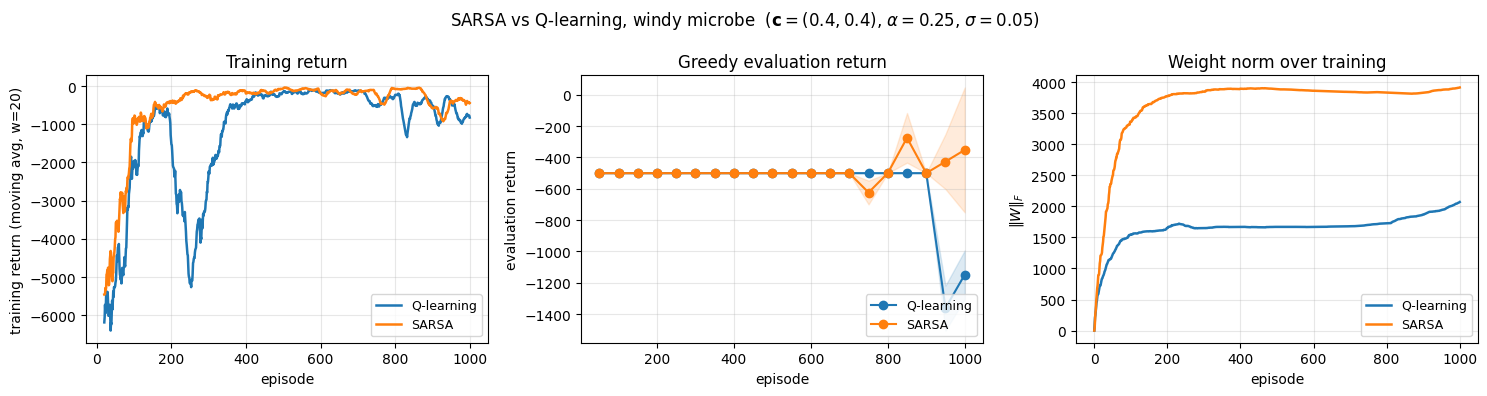

In [5]:
import matplotlib.pyplot as plt

QL_COLOR = "#1f77b4"  # blue
S_COLOR  = "#ff7f0e"  # orange
WINDOW = 20

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# (1) Training return: smoothed, both agents overlaid.
ax = axes[0]
for hist, color, label in [(q_history, QL_COLOR, "Q-learning"),
                           (s_history, S_COLOR, "SARSA")]:
    returns = np.asarray(hist.episode_returns)
    if len(returns) >= WINDOW:
        smoothed = np.convolve(returns, np.ones(WINDOW) / WINDOW, mode="valid")
        ax.plot(np.arange(WINDOW, len(returns) + 1), smoothed,
                color=color, linewidth=1.8, label=label)
ax.set_xlabel("episode")
ax.set_ylabel(f"training return (moving avg, w={WINDOW})")
ax.set_title("Training return")
ax.legend(loc="lower right", fontsize=9)
ax.grid(alpha=0.3)

# (2) Greedy evaluation return: mean ± std band.
ax = axes[1]
for hist, color, label in [(q_history, QL_COLOR, "Q-learning"),
                           (s_history, S_COLOR, "SARSA")]:
    eps = np.asarray(hist.eval_episodes)
    means = np.asarray(hist.eval_mean_returns)
    stds = np.asarray(hist.eval_std_returns)
    ax.plot(eps, means, marker="o", color=color, linewidth=1.5, label=label)
    ax.fill_between(eps, means - stds, means + stds, color=color, alpha=0.15)
ax.set_xlabel("episode")
ax.set_ylabel("evaluation return")
ax.set_title("Greedy evaluation return")
ax.legend(loc="lower right", fontsize=9)
ax.grid(alpha=0.3)

# (3) Weight norm over training, both agents overlaid.
ax = axes[2]
for ag, color, label in [(q_agent, QL_COLOR, "Q-learning"),
                         (s_agent, S_COLOR, "SARSA")]:
    norms = np.asarray(ag.weight_norms)
    ax.plot(np.arange(len(norms)), norms, color=color, linewidth=1.8, label=label)
ax.set_xlabel("episode")
ax.set_ylabel(r"$\|W\|_F$")
ax.set_title("Weight norm over training")
ax.legend(loc="lower right", fontsize=9)
ax.grid(alpha=0.3)

fig.suptitle(
    rf"SARSA vs Q-learning, windy microbe  "
    rf"($\mathbf{{c}} = {CURRENT}$, $\alpha = {NOMINAL_ALPHA}$, "
    rf"$\sigma = {NOISE}$)",
)
fig.tight_layout()
plt.show()

## Visualising the two distributions

For each agent we collect two state-visit histograms over the dish. The first is under the **behaviour policy** — ε-greedy at the agent's final $\varepsilon$, the policy that produced the data the algorithm learned from. The second is under the **target policy** — the policy whose value the bootstrap is fitting. For Q-learning the target policy is the *greedy* one, $\arg\max_a \hat{q}(s, a; \mathbf{w})$, since the bootstrap uses $\max_a$. For SARSA the target policy is the *same ε-greedy policy that generates the data*, since the bootstrap uses the action $A_{t+1}$ sampled by the behaviour. The four heatmaps are the empirical signature of the on-policy / off-policy asymmetry: for SARSA the two coincide up to sampling noise; for Q-learning they differ.

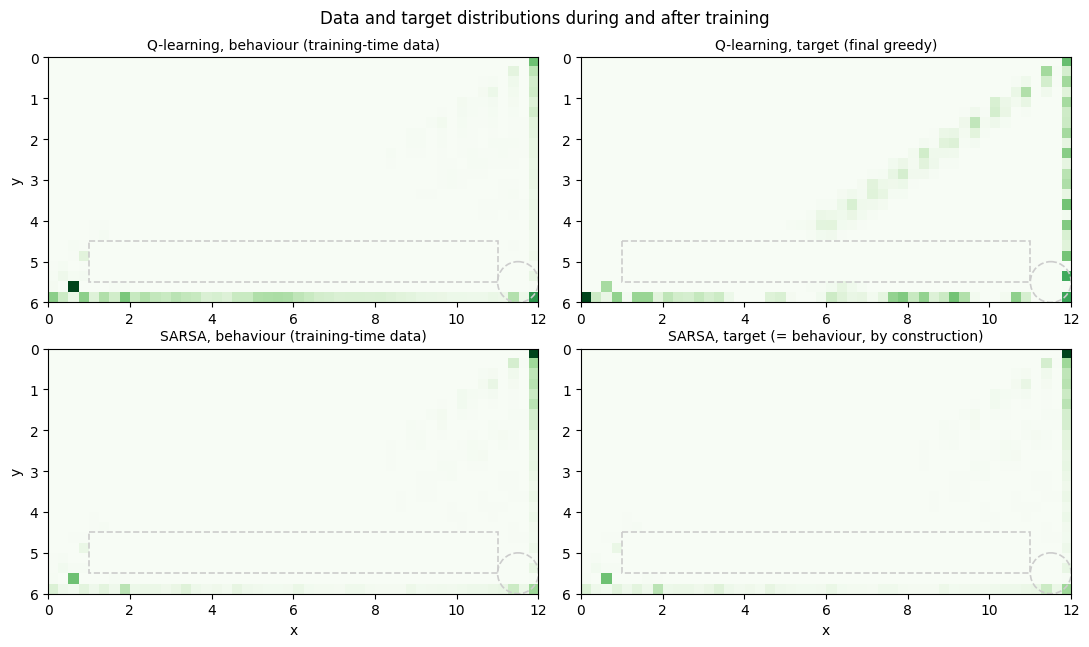

In [8]:
import matplotlib.pyplot as plt
import numpy as np


def collect_state_density(agent, env, n_episodes, *, greedy_actions, max_steps=500):
    """Run agent for n_episodes; return all visited states as an (N, 2) array."""
    states = []
    for _ in range(n_episodes):
        obs, _ = env.reset()
        steps = 0
        while True:
            states.append(obs.copy())
            action = agent.select_action(obs, greedy=greedy_actions)
            obs, _, term, trunc, _ = env.step(action)
            steps += 1
            if term or trunc:
                break
            if steps >= max_steps:
                break
    return np.array(states)


N_DENSITY_EPISODES = 60
MAX_DENSITY_STEPS = 500


def make_density_env():
    return WindyMicrobeEnv(current=CURRENT, noise=NOISE)


# --- Behaviour panels: states visited during training. ---
# These are the data each algorithm processed — broad, because ε was high
# early on and decayed only gradually. Recorded by the tracked agents during
# the training cells above, accumulating across all 1000 episodes.
ql_behaviour_states = np.array(q_agent.training_states)
s_behaviour_states  = np.array(s_agent.training_states)

# --- Target panels: distributions induced by each agent's target policy. ---
# For Q-learning, the bootstrap evaluates max_a Q(s', a'): the implicit target
# is the greedy policy. We render its distribution by rolling out the trained
# agent under greedy action selection.
ql_target_states = collect_state_density(q_agent, make_density_env(),
                                          N_DENSITY_EPISODES,
                                          greedy_actions=True,
                                          max_steps=MAX_DENSITY_STEPS)

# For SARSA, the bootstrap evaluates Q(s', a') with a' sampled by behaviour:
# data and target are the same distribution, by construction over the entire
# training run. We render this identity by reusing the behaviour panel
# verbatim — no fresh rollout, because there is no different distribution
# to sample.
s_target_states = s_behaviour_states


def state_histogram(states, bins=(48, 24),
                    x_range=(0.0, 12.0), y_range=(0.0, 6.0)):
    """2D state-density histogram, peak-normalised so panels are comparable
    in shape regardless of total sample count (training-time data has
    many more samples than post-training rollouts)."""
    H, _, _ = np.histogram2d(
        states[:, 0], states[:, 1],
        bins=bins,
        range=[list(x_range), list(y_range)],
    )
    H = H.T
    if H.max() > 0:
        H = H / H.max()
    return H


def plot_density(ax, density, title, vmax):
    ax.imshow(density, extent=(0, 12, 6, 0),
              origin="upper", cmap="Greens", vmin=0, vmax=vmax)
    ax.add_patch(plt.Rectangle((1.0, 4.5), 10.0, 1.0,
                               facecolor="none", edgecolor="#cccccc",
                               linewidth=1.2, linestyle="--"))
    ax.add_patch(plt.Circle((11.5, 5.5), 0.5,
                            facecolor="none", edgecolor="#cccccc",
                            linewidth=1.2, linestyle="--"))
    ax.set_aspect("equal")
    ax.set_xlim(0, 12)
    ax.set_ylim(6, 0)
    ax.set_title(title, fontsize=10)


densities = {
    "Q-learning, behaviour (training-time data)":    state_histogram(ql_behaviour_states),
    "Q-learning, target (final greedy)":             state_histogram(ql_target_states),
    "SARSA, behaviour (training-time data)":         state_histogram(s_behaviour_states),
    "SARSA, target (= behaviour, by construction)":  state_histogram(s_target_states),
}
shared_vmax = 1.0  # all histograms peak-normalised

fig, axes = plt.subplots(2, 2, figsize=(11, 6.5))
positions = [(0, 0), (0, 1), (1, 0), (1, 1)]
for (row, col), (title, density) in zip(positions, densities.items()):
    plot_density(axes[row, col], density, title, shared_vmax)

axes[1, 0].set_xlabel("x")
axes[1, 1].set_xlabel("x")
axes[0, 0].set_ylabel("y")
axes[1, 0].set_ylabel("y")
fig.suptitle("Data and target distributions during and after training")
fig.tight_layout()
plt.show()

The two rows of heatmaps make the section-2 discussion concrete.

In the SARSA row, the two panels are essentially identical — the same dish-coverage pattern, the same intensities, the same shape near the toxic band. Up to the noise of finite sampling they *are* the same distribution: SARSA's behaviour and target are the same ε-greedy policy, by construction. The visual identity of the two panels is the on-policy property displayed.

In the Q-learning row, the two panels differ. The behaviour panel shows the broader cloud of an ε-greedy explorer: density spread across the dish, including regions the optimal policy would never voluntarily visit. The target panel shows the sharper concentration of the greedy policy: a thinner band along the path from start to goal, with little mass in the explored periphery. These are two distributions whose overlap is partial — and Q-learning's update reads its data from the first while building its target from the second.

The visual asymmetry is the structural pre-condition for the off-policy failure mode that section 2 anticipated, made tangible. SARSA, by collapsing the two distributions into one, eliminates the pre-condition. So have we solved the problem? In a sense, yes: switching to SARSA removes this lecture's failure mode, and a practitioner who can stay on-policy can sleep easily. In a deeper sense, no — many problems force us into off-policy learning, where switching algorithm is not an option. We need to understand *why* the asymmetry between the two distributions destabilises the algorithm, not just to avoid it. The next section identifies the failure structurally, as a configuration of three properties that fail when combined.

## The deadly triad

Sutton and Barto coined the phrase **deadly triad** for the configuration of three properties that jointly produce the failure mode we have been circling: bootstrapping, off-policy learning, and function approximation. Linear Q-learning has all three by default, and we have argued — informally, and partly empirically — that this is the source of its instability. The point of this section is to make the argument tight: to identify each ingredient precisely, to verify that any *pair* of the three is harmless on its own, and to give the structural reason their *combination* is not.

What is genuinely new in this section, relative to section 2, is the third pair and the systematic statement of joint necessity: two of three is always fine; three of three is the danger.

### The three ingredients

We have met all three. We restate them precisely.

**Bootstrapping** is the use of current value estimates as components of the targets the algorithm fits. Q-learning's target $R_{t+1} + \gamma \max_{a'} \hat{q}(S_{t+1}, a'; \mathbf{w})$ is a bootstrap target: the second term is itself a value estimate, computed under the same parameters the algorithm is updating. The alternative is **Monte Carlo**, where the target is the full return $G_t$ — a quantity that depends only on observed rewards, not on the model.

**Off-policy** learning is the situation in which the data distribution and the target distribution differ. Q-learning is off-policy by construction (section 2): its bootstrap targets the *greedy* policy while its data is generated by ε-greedy. The alternative is **on-policy**, where the two coincide: SARSA.

**Function approximation** is the use of a parametric model $\hat{q}(s, a; \mathbf{w})$ with $\mathbf{w}$ a parameter vector smaller than the state-action space. The alternative is **tabular**, with one independent parameter per state-action pair. Function approximation buys generalisation across states; the cost is parameter coupling across states.

The setup of this lecture has all three. The setup of Lecture 3 had all three as well — Q-learning is off-policy regardless of environment — but the failure mode did not surface, because the spectral structure of the iteration in that particular env/feature/step-size configuration happened to be benign. Today's windy microbe and slightly more aggressive step size have nudged the configuration into a regime where the failure does surface. Lectures 1 and 2 had bootstrap + off-policy but no FA: tabular Q-learning, which converges unconditionally.

### Each pair is benign on its own

Take any two of the three ingredients and the resulting algorithm is well-behaved.

**Bootstrap and off-policy, but no FA: tabular Q-learning.** Convergence to $q^*$. The off-policy nature affects only the *speed* of convergence, not its *destination*, because each Q-table entry is updated independently of the others.

**Bootstrap and FA, but on-policy: linear semi-gradient TD.** Convergence to the projected Bellman fixed point. The bootstrap composes with the projection to a contraction in the on-policy weighted norm; this is the structure that fails when the on-policy assumption is removed.

**Off-policy and FA, but no bootstrap: off-policy Monte Carlo with a function approximator.** With Monte Carlo targets $G_t$, the quantity being fit does not depend on $\mathbf{w}$ — it is a sample of the true return, conditional on the trajectory only. The algorithm reduces to ordinary stochastic gradient descent on a fixed loss, and standard convergence theory applies regardless of the data distribution. Off-policy data only changes *which* loss is being minimised (a re-weighted MSE), not whether the minimisation is well-defined.

In each pair, *something* prevents disaster: parameters are independent (no FA), data and target are aligned (on-policy), or targets are fixed during the update (no bootstrap). Remove any one of the three ingredients and the algorithm has a fixed point and converges to it.

### Why the three together fail

Combining all three deprives us of all three protections at once.

Bootstrapping ties the target to the current parameter vector: the quantity being fit *moves* as the parameters change. Function approximation couples updates across states: changing $\mathbf{w}$ at one state changes the predicted value at every state with overlapping features. Off-policy weighting decouples the data's geometry from the target's geometry: the projected Bellman operator, viewed in the data-weighted norm, is no longer a contraction in general.

The result is a system in which a single update can simultaneously change the prediction at many states *and* change the bootstrap targets at many states, with the data weighting failing to align these changes toward a balance point. In the forces metaphor of section 2, the forces no longer cancel — not because they are individually stronger, but because there is no equilibrium for them to cancel at. With on-policy data the forces would cancel at the on-policy projected fixed point; without bootstrapping the targets would not move; without function approximation the parameters could not interact. With all three, none of these stabilising structures is present.

### What the triad explains and what it does not

The triad explains why Q-learning with linear features *can* fail. It does not say it *will* fail in every problem with all three ingredients — many problems where the algorithm is nominally off-policy with FA still converge, because the spectral structure of the relevant matrices happens to be benign. The triad is a *structural pre-condition*, not a guarantee. Lecture 3 had all three ingredients and converged; the windy microbe of this lecture has all three and is unstable. 

This matters in practice. The standard remedies — target networks, experience replay, gradient TD methods, careful feature engineering — do not remove the triad (we still have all three ingredients in DQN), but they *modify* the spectral structure of the iteration so that the dangerous configurations become rare. The next section demonstrates the failure mode in its purest form on Baird's example. The section after that surveys the remedies.

### What goes wrong, intuitively

Before constructing a problem where divergence is certified, it helps to picture the failure mechanism. The triad's three ingredients fit together as a self-amplifying loop. Bootstrap makes the target a function of $\mathbf{w}$: when $\mathbf{w}$ moves, the target moves. Function approximation couples states: updating $\mathbf{w}$ to reduce the TD error at one state changes the predicted value, and therefore the bootstrap target, at every state with overlapping features. Off-policy weighting denies the loop the natural damping that on-policy data provides — the alignment between data distribution and target structure that on-policy methods enjoy.

The result is a feedback loop with no built-in equilibrium. An update at one state to reduce TD error there propagates a change to targets at other states, creating new TD errors, which provoke further updates, which propagate further. In a benign environment this loop is gentle and the parameters drift to a sub-optimal but stable region — Lecture 3 lived in this regime. In an adversarial environment the loop is divergent: each iteration creates more error than it removes, and the parameter vector grows without bound. The next thing we will do is construct such an adversarial environment, simple enough to inspect by hand and adversarial enough to make divergence inevitable.

## Baird's counterexample

Baird (1995) defined the following minimal Markov decision process to demonstrate that linear semi-gradient off-policy TD can diverge.

The MDP has **seven states**, numbered 1 through 7, and **two actions** which we will call *solid* and *dashed*. The transitions are simple. The *solid* action transitions deterministically to state 7, regardless of the starting state. The *dashed* action transitions to one of states 1–6, uniformly at random, regardless of the starting state. All rewards are zero, so the true value function under any policy is identically zero: any algorithm that learns the value function correctly should converge to a parameter vector that produces $\hat{V}(s) = 0$ for every $s$. The discount is $\gamma = 0.99$.

The behaviour policy chooses *solid* with probability $1/7$ and *dashed* with probability $6/7$; this choice produces a uniform stationary distribution over the seven states, which is the simplest setting against which to study off-policy dynamics. The target policy is deterministic: it chooses *solid* in every state, and therefore — if we rolled it out — would concentrate all its visited mass on state 7.

The feature representation is the load-bearing piece of the construction. Each state is mapped to a vector in $\mathbb{R}^8$. States 1 through 6 share the same structural pattern: state $i$ has a 2 in the $i$-th component and a 1 in the eighth component, with all other components zero. State 7 has a 1 in the seventh component and a 2 in the eighth component, again with all other components zero. There are eight parameters but only seven states, and the feature matrix is rank 7 with a specific linear dependency that, combined with the transition dynamics, produces the failure.

The initial weights are $\mathbf{w}_0 = (1, 1, 1, 1, 1, 1, 10, 1)$. The choice of an inflated value for the seventh component is not innocent: it gives the algorithm something to amplify. The induced initial values are $\hat{V}(s_i) = 3$ for $i = 1, \ldots, 6$ and $\hat{V}(s_7) = 12$ — far from the true value of zero, in a direction that the dynamics will exaggerate.

We run linear semi-gradient off-policy TD(0) in its **expected-update form**, applying at each iteration the average update over the behaviour stationary distribution and the target's deterministic transitions. This is mathematically equivalent to averaging the per-sample importance-sampled TD updates over many samples, and removes the stochastic noise that would otherwise obscure the divergence dynamics — leaving the underlying behaviour of the iteration visible directly.

In [18]:
import numpy as np

# --- MDP definition ---
N_STATES = 7
N_FEATURES = 8
TARGET_NEXT_STATE = 6  # The "central" state (1-based "state 7"), 0-indexed.

# Feature matrix: row i is φ(state i) for i = 0, 1, ..., 6.
Phi = np.zeros((N_STATES, N_FEATURES))
for i in range(6):
    Phi[i, i] = 2.0   # state-specific component
    Phi[i, 7] = 1.0   # shared component
Phi[6, 6] = 1.0       # central state's specific component
Phi[6, 7] = 2.0       # central state's shared component (2x normal)

print(Phi)

# --- Initial weights, with the inflated 7th component (Baird's choice) ---
w = np.array([1, 1, 1, 1, 1, 1, 10, 1], dtype=np.float64)

# --- Algorithm parameters ---
ALPHA = 0.01
GAMMA = 0.99
N_ITERATIONS = 1000

# --- Expected off-policy TD(0) iteration ---
# At each step, the bootstrap target at every state is γ V̂(s_7), since the
# target policy goes deterministically to state 7. We compute the expected
# update over the behaviour's uniform stationary distribution and apply it.
weight_history = [w.copy()]
value_history  = [Phi @ w]

for t in range(N_ITERATIONS):
    V_target_next = Phi[TARGET_NEXT_STATE] @ w
    update = np.zeros_like(w)
    for s in range(N_STATES):
        V_s = Phi[s] @ w
        td_error = GAMMA * V_target_next - V_s
        update += td_error * Phi[s]
    update /= N_STATES                    # average over uniform d_b
    w = w + ALPHA * update
    weight_history.append(w.copy())
    value_history.append(Phi @ w)

weight_history = np.array(weight_history)
value_history  = np.array(value_history)
weight_norms   = np.linalg.norm(weight_history, axis=1)

print(f"Initial ||w||:                    {weight_norms[0]:.3f}")
print(f"Final   ||w|| after {N_ITERATIONS} iters: {weight_norms[-1]:.3e}")
print(f"Growth factor:                     {weight_norms[-1] / weight_norms[0]:.3e}")
print(f"Final V̂(s_7) (true value: 0):     {value_history[-1, 6]:.3e}")

[[2. 0. 0. 0. 0. 0. 0. 1.]
 [0. 2. 0. 0. 0. 0. 0. 1.]
 [0. 0. 2. 0. 0. 0. 0. 1.]
 [0. 0. 0. 2. 0. 0. 0. 1.]
 [0. 0. 0. 0. 2. 0. 0. 1.]
 [0. 0. 0. 0. 0. 2. 0. 1.]
 [0. 0. 0. 0. 0. 0. 1. 2.]]
Initial ||w||:                    10.344
Final   ||w|| after 1000 iters: 4.369e+02
Growth factor:                     4.223e+01
Final V̂(s_7) (true value: 0):     6.769e+02


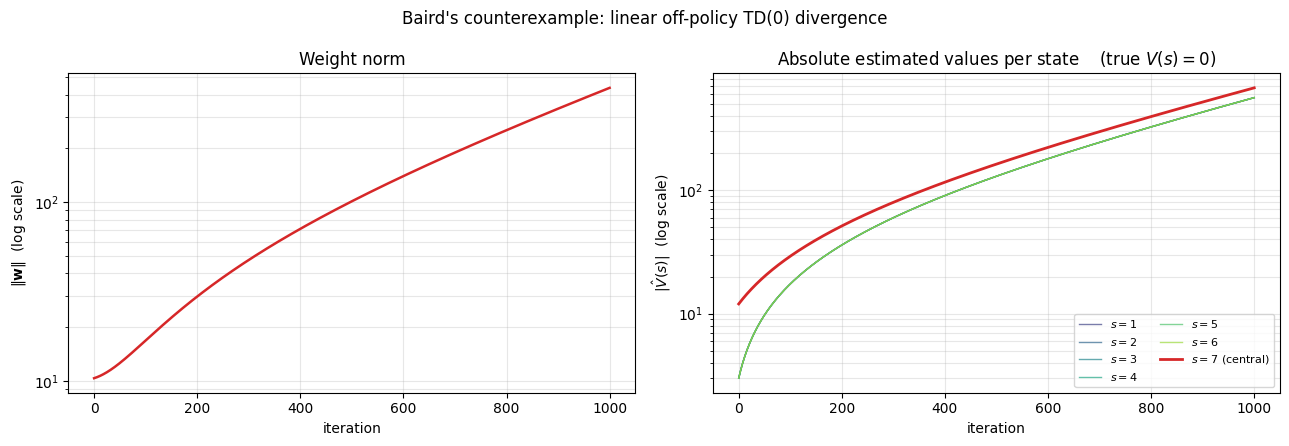

In [19]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# (1) ||w|| over iterations, log scale.
ax = axes[0]
iters = np.arange(len(weight_norms))
ax.semilogy(iters, weight_norms, color="#d62728", linewidth=1.8)
ax.set_xlabel("iteration")
ax.set_ylabel(r"$\|\mathbf{w}\|$  (log scale)")
ax.set_title("Weight norm")
ax.grid(alpha=0.3, which="both")

# (2) |V̂(s)| over iterations, log scale, all 7 states.
ax = axes[1]
state_colors = plt.cm.viridis(np.linspace(0.2, 0.85, 6))
for s in range(6):
    ax.semilogy(iters, np.abs(value_history[:, s]),
                color=state_colors[s], linewidth=1.0, alpha=0.7,
                label=f"$s = {s+1}$")
ax.semilogy(iters, np.abs(value_history[:, 6]),
            color="#d62728", linewidth=2.0, label="$s = 7$ (central)")
ax.set_xlabel("iteration")
ax.set_ylabel(r"$|\hat{V}(s)|$  (log scale)")
ax.set_title(r"Absolute estimated values per state    (true $V(s) = 0$)")
ax.legend(loc="lower right", fontsize=8, ncol=2)
ax.grid(alpha=0.3, which="both")

fig.suptitle("Baird's counterexample: linear off-policy TD(0) divergence")
fig.tight_layout()
plt.show()

## Reading Baird's divergence

The two panels say the same thing in two ways. The weight norm, on the left, follows a roughly straight line on log scale — the signature of geometric growth. Each iteration multiplies $\|\mathbf{w}\|$ by approximately the same factor, and $\|\mathbf{w}\|$ heads to infinity at a rate that does not decrease. The estimated values, on the right, show the same geometric divergence at the level of the function the weights induce: $|\hat{V}(s)|$ grows at a constant rate for every state, while the true value is zero everywhere by construction.

The construction is artificial. The MDP is small, the transition structure is unrealistic, the features are hand-chosen, and the initialisation is deliberately inflated. Baird made every choice with one purpose: to produce, in the simplest possible setting, a configuration in which linear off-policy TD demonstrably diverges. The pedagogical value is in the fact that *this is possible at all* — that a benign-looking linear approximator with reasonable hyperparameters can fail to converge on a problem with zero rewards and a constant-zero true value function. The failure is not a numerical accident or a tuning issue: every iteration moves the parameters further from the truth, by an amount that grows.

What connects this to the windy microbe of section 5? Structurally, both setups have the same configuration: bootstrap, off-policy data, function approximation. The difference is in the details — in the spectrum of the iteration that section 7 alluded to, and in the specifics of the transitions, the features, and the data distribution. Baird's construction is engineered so that the dangerous configuration dominates and divergence is geometric and unambiguous; the windy microbe sits in a regime where the same configuration is present but the dynamics are slow and the parameters drift rather than explode. The deadly triad makes both situations possible. The specifics of the environment and the algorithm determine which one we land in. The next section asks what we can do about it.

### How the divergence unfolds, step by step

The dynamics are easiest to follow if we trace one iteration of the algorithm and ask what has changed. The initial weights produce $\hat{V}(s_1) = \cdots = \hat{V}(s_6) = 3$ and $\hat{V}(s_7) = 12$ — the central state's value is inflated by the deliberate choice of $w_7 = 10$.

**What the algorithm sees as a TD error.** The target policy goes to state 7 from any state, so the bootstrap target everywhere is $\gamma \hat{V}(s_7) = 0.99 \cdot 12 = 11.88$. At each non-central state the TD error is therefore $\gamma \hat{V}(s_7) - \hat{V}(s_i) = 11.88 - 3 = 8.88$ — a large positive error: **the algorithm sees its predictions at all six non-central states as far below the target, and asks to push them *upward*.** At the central state itself the target is the same — $\gamma \hat{V}(s_7) = 11.88$ — but the value being compared to is now $\hat{V}(s_7) = 12$, so the TD error is $11.88 - 12 = -0.12$, much smaller in magnitude and slightly negative. The asymmetry is structural: the target is identical for every state (since the target policy goes to $s_7$ from anywhere), but at $s_7$ the current value is already very close to the discounted target, while at the six non-central states it is far below.

**How the parameters move.** The semi-gradient update at state $s_i$ (for $i \leq 6$) pushes the weights in the direction of $\phi(s_i)$, scaled by the TD error. The non-zero components of $\phi(s_i)$ are the $i$-th component (value 2) and the eighth (value 1). The algorithm therefore pushes both $w_i$ and $w_8$ upward — and $w_8$ is the *shared* component used by all seven states. The update at $s_7$ pushes $w_7$ and $w_8$ slightly downward, but with a much smaller magnitude (0.12 vs. 8.88) and weighted by only one state out of seven.

**The side effect.** Increasing $w_8$ does not just raise $\hat{V}(s_i)$; it also raises $\hat{V}(s_7) = w_7 + 2 w_8$, which contains $w_8$ with coefficient *2* — twice the coefficient at any non-central state. The bootstrap target $\gamma \hat{V}(s_7)$ that the algorithm was chasing has grown as a side effect of the algorithm's own update. The TD error at the next iteration is therefore *larger*, not smaller.

**The closing of the loop.** A larger TD error produces a larger update on $w_8$. A larger $w_8$ produces a higher $\hat{V}(s_7)$. A higher $\hat{V}(s_7)$ produces a still larger TD error. There is no force strong enough to damp the cycle: the only state whose value is "too high" relative to its bootstrap target is $s_7$ itself, and its TD error remains proportional to $1 - \gamma = 0.01$, vanishingly small; the negative pressure it exerts on $w_8$ is dwarfed by the positive pressure from the six non-central states. The parameters grow, the target grows, the TD error grows, the parameters grow more — geometrically, with a constant ratio per iteration. Each round of the loop creates more error than the algorithm fixes; the next round amplifies the new error, and so on.

**Why this is specifically off-policy.** In an on-policy run — for instance, evaluating the behaviour policy itself rather than the deterministic-solid target — the bootstrap target at each state would be a weighted average of $\hat{V}$ at successor states under the *behaviour* dynamics, not just $\hat{V}(s_7)$. State 7 would no longer dominate the targets uniformly, and the contribution of each state to the update would be properly weighted by its on-policy visit frequency. The contraction in the on-policy weighted norm — the structure that section 2 invoked — would damp the loop at each round. Off-policy evaluation removes that damping: the bootstrap always points to state 7's value, regardless of where the data comes from, and the **asymmetry between *six states pushing $w_8$ up* and *one state pushing $w_8$ down weakly* is structurally decisive**.

In [20]:
import numpy as np

# --- MDP definition ---
N_STATES = 7
N_FEATURES = 8
TARGET_NEXT_STATE = 6  # The "central" state (1-based "state 7"), 0-indexed.

Phi = np.zeros((N_STATES, N_FEATURES))
for i in range(6):
    Phi[i, i] = 2.0
    Phi[i, 7] = 1.0
Phi[6, 6] = 1.0
Phi[6, 7] = 2.0

# --- Algorithm parameters ---
ALPHA = 0.01
GAMMA = 0.99
N_ITERATIONS = 1000


def show_state(w, label):
    V = Phi @ w
    print(f"{label}:")
    print(f"   w[6] (s_7's specific) = {w[6]:.4g}")
    print(f"   w[7] (shared)         = {w[7]:.4g}")
    print(f"   V̂(s_1..6)             = {V[0]:.4g}   (equal by symmetry)")
    print(f"   V̂(s_7)                = {V[6]:.4g}")
    print(f"   target  γ·V̂(s_7)      = {GAMMA*V[6]:.4g}")
    print(f"   TD error non-central  = {GAMMA*V[6] - V[0]:+.4g}")
    print(f"   TD error central      = {GAMMA*V[6] - V[6]:+.4g}")


def step(w):
    """One expected off-policy TD(0) update; returns new weights."""
    V_target_next = Phi[TARGET_NEXT_STATE] @ w
    update = np.zeros_like(w)
    for s in range(N_STATES):
        V_s = Phi[s] @ w
        td_error = GAMMA * V_target_next - V_s
        update += td_error * Phi[s]
    update /= N_STATES
    return w + ALPHA * update


# --- Initialise weights and history buffers ---
w = np.array([1, 1, 1, 1, 1, 1, 10, 1], dtype=np.float64)
weight_history = [w.copy()]
value_history  = [Phi @ w]


# --- Iteration 0: starting position ---
show_state(w, "Iteration 0  (initial)")
print()
print("   Non-central TD error is large positive (+8.88), central is small negative")
print("   (-0.12). The shared component w[7] will be pushed upward; the non-central")
print("   pressure dominates six-to-one.")
print()


# --- Iteration 1 ---
w = step(w); weight_history.append(w.copy()); value_history.append(Phi @ w)
show_state(w, "Iteration 1")
print()
print(f"   w[7] grew from 1 to {w[7]:.4g}. V̂(s_7) grew more than V̂(s_1..6), because")
print("   s_7's feature has w[7] with coefficient 2 instead of 1. The bootstrap")
print("   target γ·V̂(s_7) grew with it: the gap to close is now *larger*, not")
print("   smaller, than before the update.")
print()


# --- Iteration 2 ---
w = step(w); weight_history.append(w.copy()); value_history.append(Phi @ w)
show_state(w, "Iteration 2")
print()
print("   Same pattern, slightly amplified. Per-iteration growth of V̂(s_7) is")
print("   around 1.3% — modest, but persistent and self-amplifying.")
print()


# --- Iteration 50 ---
for _ in range(48):
    w = step(w); weight_history.append(w.copy()); value_history.append(Phi @ w)
show_state(w, "Iteration 50")
print()
print(f"   V̂(s_7) is now {value_history[-1][6]:.4g}, well above its initial value of 12,")
print("   and the TD errors have grown proportionally. Compounding has taken over.")
print()


# --- Iteration 1000 ---
for _ in range(N_ITERATIONS - 50):
    w = step(w); weight_history.append(w.copy()); value_history.append(Phi @ w)
show_state(w, f"Iteration {N_ITERATIONS}")
print()
print(f"   V̂(s_7), whose true value is 0 by construction, is now {value_history[-1][6]:.3e}")
print("   — several orders of magnitude away from the truth, and growing.")


# --- Convert to arrays for the plotting cell. ---
weight_history = np.array(weight_history)
value_history  = np.array(value_history)
weight_norms   = np.linalg.norm(weight_history, axis=1)

Iteration 0  (initial):
   w[6] (s_7's specific) = 10
   w[7] (shared)         = 1
   V̂(s_1..6)             = 3   (equal by symmetry)
   V̂(s_7)                = 12
   target  γ·V̂(s_7)      = 11.88
   TD error non-central  = +8.88
   TD error central      = -0.12

   Non-central TD error is large positive (+8.88), central is small negative
   (-0.12). The shared component w[7] will be pushed upward; the non-central
   pressure dominates six-to-one.

Iteration 1:
   w[6] (s_7's specific) = 10
   w[7] (shared)         = 1.076
   V̂(s_1..6)             = 3.127   (equal by symmetry)
   V̂(s_7)                = 12.15
   target  γ·V̂(s_7)      = 12.03
   TD error non-central  = +8.903
   TD error central      = -0.1215

   w[7] grew from 1 to 1.076. V̂(s_7) grew more than V̂(s_1..6), because
   s_7's feature has w[7] with coefficient 2 instead of 1. The bootstrap
   target γ·V̂(s_7) grew with it: the gap to close is now *larger*, not
   smaller, than before the update.

Iteration 2:
   w[6

### A first remedy: on-policy TD on the very same Baird MDP. 
Features, hyper-parameters, and initial weights are identical to the off-policy run above.

The single change is the bootstrap target: instead of fitting the value function of the deterministic-solid *target* policy (which always sends the agent to state 7), we fit the value function of the *behaviour* policy itself — the actual policy generating the data. Behaviour and target now coincide; the algorithm is on-policy. This is the prediction-side analogue of the SARSA design from section 4: the bootstrap evaluates the same policy that the data is drawn from.

Under the behaviour policy, the next-state distribution from any state is uniform over all seven states: solid (prob 1/7) goes deterministically to state 7, dashed (prob 6/7) goes uniformly to one of states 1-6, so each successor has total probability 1/7. The expected next-state value is therefore simply the mean of V̂ over all states.

On-policy TD on the same Baird MDP, same features, same hyperparameters,
same initial weights — only the target has changed:

   Initial ||w||:                  10.344
   Final   ||w|| after 1000 iters:   8.710     (off-policy: 4.369e+02)
   Final   V̂(s_1):                1.531     (off-policy: 5.639e+02)
   Final   V̂(s_7):                1.833     (off-policy: 6.769e+02)
   True V(s) for the behaviour:   0 for every s.


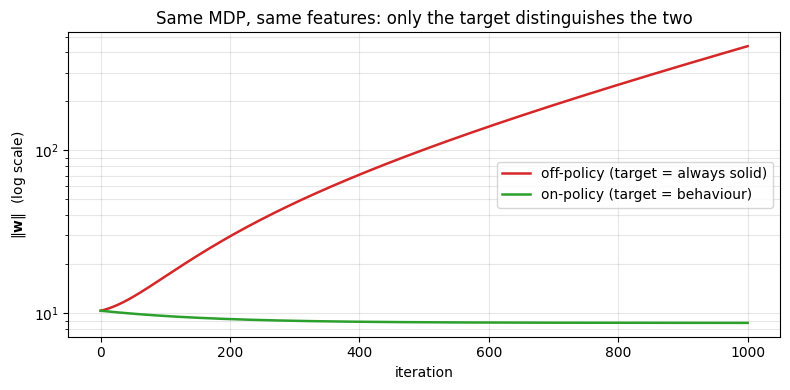

In [21]:

w_op = np.array([1, 1, 1, 1, 1, 1, 10, 1], dtype=np.float64)
weight_history_op = [w_op.copy()]
value_history_op  = [Phi @ w_op]

for t in range(N_ITERATIONS):
    V = Phi @ w_op
    expected_V_next = V.mean()                # E[V̂(s')] under behaviour
    update = np.zeros_like(w_op)
    for s in range(N_STATES):
        td_error = GAMMA * expected_V_next - V[s]
        update += td_error * Phi[s]
    update /= N_STATES
    w_op = w_op + ALPHA * update
    weight_history_op.append(w_op.copy())
    value_history_op.append(Phi @ w_op)

weight_history_op = np.array(weight_history_op)
value_history_op  = np.array(value_history_op)
weight_norms_op   = np.linalg.norm(weight_history_op, axis=1)

print("On-policy TD on the same Baird MDP, same features, same hyperparameters,")
print("same initial weights — only the target has changed:")
print()
print(f"   Initial ||w||:                  {weight_norms_op[0]:.3f}")
print(f"   Final   ||w|| after {N_ITERATIONS} iters:   {weight_norms_op[-1]:.3f}     "
      f"(off-policy: {weight_norms[-1]:.3e})")
print(f"   Final   V̂(s_1):                {value_history_op[-1, 0]:.4g}     "
      f"(off-policy: {value_history[-1, 0]:.3e})")
print(f"   Final   V̂(s_7):                {value_history_op[-1, 6]:.4g}     "
      f"(off-policy: {value_history[-1, 6]:.3e})")
print(f"   True V(s) for the behaviour:   0 for every s.")

# Side-by-side: ||w|| over iterations, both runs.
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
iters = np.arange(len(weight_norms))
ax.semilogy(iters, weight_norms, color="#d62728", linewidth=1.8,
            label="off-policy (target = always solid)")
ax.semilogy(iters, weight_norms_op, color="#2ca02c", linewidth=1.8,
            label="on-policy (target = behaviour)")
ax.set_xlabel("iteration")
ax.set_ylabel(r"$\|\mathbf{w}\|$  (log scale)")
ax.set_title("Same MDP, same features: only the target distinguishes the two")
ax.legend(loc="center right")
ax.grid(alpha=0.3, which="both")
fig.tight_layout()
plt.show()

## Closing: bridges to Lecture 5

The simplest remedy for the deadly triad — switching to on-policy, as we did with SARSA — is not always available; many practical problems require off-policy data, and we need to keep off-policy while finding another way to stabilise the algorithm. The remedies that drive deep Q-learning's architecture are two.

**Target networks.** Freeze a copy of the parameters and use the *frozen* copy to compute bootstrap targets, refreshing it only periodically. For the duration of a freeze interval the algorithm is fitting a fixed regression problem, with the standard convergence guarantees of supervised learning; the target tracks the learner without co-moving with every gradient step. This breaks the most direct part of the triad's feedback loop: the bootstrap target moving with each parameter update.

**Experience replay.** Store transitions in a buffer and sample from it for updates, rather than using the most recent transition only. The data becomes decorrelated from the policy currently executing, and the empirical data distribution is averaged over many past policies — smoothing the off-policy mismatch and bringing the iteration closer to the stationary regime in which standard stochastic optimisation theory applies.

In the linear case studied today, these two interventions are *helpful*, not strictly necessary; many linear problems converge without them. In the non-linear case of Lecture 5, with neural-network approximators that have no spectral guarantees and that turn the dangerous triad configurations from exception into rule, target networks and replay buffers are not optional fixes added to a working algorithm.